# M1 Baseline — CLIP + GPT-2 Embedding Extraction
This notebook extracts image embeddings (CLIP ViT-B/32) and text token embeddings (GPT-2) from Flickr30k.

## Section 1 — Environment Setup

In [2]:
# Clone or update the repo
import os

# Detect environment
IN_COLAB = 'COLAB_GPU' in os.environ or os.path.exists('/content')
REPO_NAME = 'Generative_Project_1'
BASE_DIR = '/content' if IN_COLAB else r'D:\NEU'
REPO_DIR = os.path.join(BASE_DIR, REPO_NAME)

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Scofe-C/Generative_Project_1.git {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull origin main

os.chdir(REPO_DIR)
import sys
sys.path.insert(0, REPO_DIR)
print(f'Working directory: {os.getcwd()}')
print(f'Environment: {"Colab" if IN_COLAB else "Local"}')

Working directory: D:\NEU\Generative_Project_1
Environment: Local


fatal: couldn't find remote ref main


## Section 2 — Configuration & Initialization

In [3]:
from src.utils import load_config, setup_logging, set_seed, get_device
from src.utils import get_per_class_target, get_candidate_pool_size, get_pipeline_mode, get_pin_memory
import torch

# Load config
config = load_config('configs/config.yaml')
setup_logging(config)
set_seed(config['dataset']['seed'])

# Detect device
device = get_device()

print(f'Pipeline mode   : {get_pipeline_mode(config)}')
print(f'Dataset         : {config["dataset"]["name"]}')
print(f'Device          : {device}')
print(f'Batch size      : {config["hardware"]["batch_size"]}')

if device.type == 'cuda':
    free_vram = torch.cuda.mem_get_info(0)[0] / 1e9
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM            : {free_vram:.1f} / {total_vram:.1f} GB')

assert config['hardware']['batch_size'] <= 64, 'batch_size too high — risk of OOM'

2026-03-01 20:57:34 | INFO     | src.utils | Random seed set to 42
2026-03-01 20:57:34 | INFO     | src.utils | Device selected: CUDA | NVIDIA GeForce RTX 4060 Laptop GPU | VRAM: 8.6 GB | CUDA 12.1
Pipeline mode   : extract
Dataset         : nlphuji/flickr30k
Device          : cuda
Batch size      : 32
VRAM            : 7.4 / 8.6 GB


In [4]:
# Verify model configs before downloading data
from transformers import AutoConfig

clip_cfg = AutoConfig.from_pretrained(config['models']['clip'])
gpt2_cfg = AutoConfig.from_pretrained(config['models']['gpt2'])

CLIP_EMBED_DIM = clip_cfg.projection_dim
GPT2_HIDDEN_DIM = gpt2_cfg.n_embd

print(f'CLIP: {config["models"]["clip"]} → projection_dim={CLIP_EMBED_DIM}')
print(f'GPT2: {config["models"]["gpt2"]} → hidden_size={GPT2_HIDDEN_DIM}')
print('Models verified ✓')

D:\NEU\Generative_Project_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CLIP: openai/clip-vit-base-patch32 → projection_dim=512
GPT2: gpt2 → hidden_size=768
Models verified ✓


D:\NEU\Generative_Project_1\.venv\Lib\site-packages\huggingface_hub\file_download.py:159: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\17160\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
D:\NEU\Generative_Project_1\.venv\Lib\site-packages\huggingface_hub\file_download.py:159: UserWarning:

In [6]:
# Create output directories
from pathlib import Path
from src.utils import get_output_path

output_path = get_output_path(config)
Path(config['logging']['log_dir']).mkdir(parents=True, exist_ok=True)
Path('checkpoints').mkdir(exist_ok=True)

print(f'Output path    : {output_path}')
print('Directories ready')

Output path    : D:\NEU\Generative_Project_1\outputs\embeddings.npz
Directories ready


## Section 3 — Data Loading
Download Flickr30k once, scan for best classes, build candidate pool — all in one pass.

In [7]:
import logging
logging.getLogger('httpx').setLevel(logging.WARNING)
logging.getLogger('huggingface_hub').setLevel(logging.WARNING)
logging.getLogger('huggingface_hub.utils._http').setLevel(logging.WARNING)
logging.getLogger('filelock').setLevel(logging.WARNING)

from datasets import load_dataset
from collections import Counter
import random
from src.data_loader import COCO_CLASS_ALIASES
from src.utils import set_seed, get_per_class_target

# ── Step 1: Download dataset once ──
print('Downloading Flickr30k...')
ds = load_dataset('nlphuji/flickr30k', split='test', revision='refs/convert/parquet')
print(f'Loaded {len(ds)} images\n')

# ── Step 2: Scan for best classes ──
nouns = [
    'man', 'woman', 'boy', 'girl', 'child', 'dog', 'cat', 'car', 'bike',
    'bicycle', 'horse', 'bird', 'ball', 'water', 'street', 'grass', 'snow',
    'beach', 'building', 'bridge', 'hat', 'shirt', 'boat', 'bus', 'train',
    'sign', 'bench', 'tree', 'field', 'rock', 'baby', 'crowd', 'helmet',
    'guitar', 'player', 'food', 'table', 'chair', 'group', 'people',
    'soccer', 'pool', 'mountain', 'jacket', 'dress', 'bag', 'door',
    'fence', 'flower', 'umbrella', 'kid', 'road', 'river', 'ocean', 'park',
    'bottle', 'cup', 'camera', 'phone', 'laptop', 'book', 'flag', 'toy'
]
counts = Counter()
for sample in ds:
    text = ' '.join(sample['caption']).lower()
    for noun in nouns:
        if noun in text:
            counts[noun] += 1

top10 = [w for w, c in counts.most_common() if c >= 300][:10]
print('Top 10 classes (all 300+):')
for w in top10:
    print(f'  {w:<15}: {counts[w]}')

# ── Step 3: Update config ──
config['dataset']['classes'] = top10
config['dataset']['target_n'] = len(top10) * 100
for cls in top10:
    COCO_CLASS_ALIASES[cls] = [cls]

per_class = get_per_class_target(config)
multiplier = config['dataset']['pool_multiplier']
per_class_pool_target = per_class * multiplier

# ── Step 4: Build candidate pool from already-downloaded data ──
print(f'\nBuilding candidate pool (target {per_class_pool_target} per class)...')
set_seed(config['dataset']['seed'])
buckets = {cls: [] for cls in top10}

for sample in ds:
    if all(len(buckets[c]) >= per_class_pool_target for c in top10):
        break
    text = ' '.join(sample['caption']).lower()
    for cls in top10:
        if cls in text and len(buckets[cls]) < per_class_pool_target:
            buckets[cls].append({
                'image_id': str(sample.get('img_id', 'unknown')),
                'image': sample['image'],
                'captions': sample['caption'],
                'label': cls,
            })
            break

print('\nCandidate pool summary:')
total = 0
for cls, records in buckets.items():
    status = '✓' if len(records) >= per_class_pool_target else f'SHORT by {per_class_pool_target - len(records)}'
    print(f'  {cls:<12}: {len(records):>4}  {status}')
    total += len(records)
print(f'  {"TOTAL":<12}: {total:>4}')

2026-03-01 20:58:26 | INFO     | datasets | PyTorch version 2.5.1+cu121 available.


Generating test split: 31014 examples [00:05, 5480.69 examples/s]


Loaded 31014 images

Top 10 classes (all 300+):
  man            : 19629
  shirt          : 9041
  woman          : 7880
  people         : 7808
  tree           : 5472
  hat            : 5327
  girl           : 4821
  boy            : 4599
  group          : 4574
  child          : 4450

Building candidate pool (target 300 per class)...
2026-03-01 21:00:02 | INFO     | src.utils | Random seed set to 42

Candidate pool summary:
  man         :  300  ✓
  shirt       :  300  ✓
  woman       :  300  ✓
  people      :  300  ✓
  tree        :  300  ✓
  hat         :  300  ✓
  girl        :  300  ✓
  boy         :  300  ✓
  group       :  300  ✓
  child       :  300  ✓
  TOTAL       : 3000


## Section 4 — Preprocessing
Select per-class samples, validate images, apply CLIP transforms, tokenize captions.

In [8]:
from src.data_loader import get_dataloader_splits, flatten_candidates
from src.preprocessor import Preprocessor

# Select per-class target from pool
selected = get_dataloader_splits(buckets, config)
flat = flatten_candidates(selected)
print(f'Selected {len(flat)} candidates for preprocessing\n')

# Preprocess: validate images, apply CLIP transforms, tokenize captions
preprocessor = Preprocessor(config)
preprocess_result = preprocessor.process_candidates(flat, reserve_pool=buckets)
print(f'\n{preprocess_result.summary()}')

valid_samples = preprocess_result.valid_samples
print(f'\nReady for embedding extraction: {len(valid_samples)} samples')

2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'man': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'shirt': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'woman': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'people': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'tree': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'hat': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'girl': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'boy': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'group': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loader | Class 'child': selected 100 / 300 candidates
2026-03-01 21:02:15 | INFO     | src.data_loade

D:\NEU\Generative_Project_1\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


2026-03-01 21:02:18 | INFO     | src.preprocessor | GPT2Tokenizer: set pad_token = eos_token ('<|endoftext|>')
2026-03-01 21:02:18 | INFO     | src.preprocessor | Preprocessor ready | image_size=224 | max_token_length=77 | max_retries=3
2026-03-01 21:02:18 | INFO     | src.preprocessor | Preprocessing 0/1000 | valid=0 | repaired=0 | skipped=0
2026-03-01 21:02:18 | INFO     | src.preprocessor | Preprocessing 100/1000 | valid=100 | repaired=0 | skipped=0
2026-03-01 21:02:18 | INFO     | src.preprocessor | Preprocessing 200/1000 | valid=200 | repaired=0 | skipped=0
2026-03-01 21:02:18 | INFO     | src.preprocessor | Preprocessing 300/1000 | valid=300 | repaired=0 | skipped=0
2026-03-01 21:02:19 | INFO     | src.preprocessor | Preprocessing 400/1000 | valid=400 | repaired=0 | skipped=0
2026-03-01 21:02:19 | INFO     | src.preprocessor | Preprocessing 500/1000 | valid=500 | repaired=0 | skipped=0
2026-03-01 21:02:19 | INFO     | src.preprocessor | Preprocessing 600/1000 | valid=600 | repair

## Section 5 — Embedding Extraction
Load CLIP + GPT-2, extract image and text embeddings, save to `.npz`.

In [9]:
import numpy as np
from transformers import AutoModel
from src.embeddings_io import EmbeddingCheckpointer, load_embeddings
from src.pipeline import _normalize

batch_size = config['hardware']['batch_size']

# Load models
print('Loading CLIP model...')
clip_model = AutoModel.from_pretrained(config['models']['clip']).to(device)
clip_model.eval()

print('Loading GPT-2 model...')
gpt2_model = AutoModel.from_pretrained(config['models']['gpt2']).to(device)
gpt2_model.eval()

# Create projection layer once (768 → 512)
text_projection = None
if gpt2_model.config.n_embd != clip_model.config.projection_dim:
    text_projection = torch.nn.Linear(
        gpt2_model.config.n_embd,
        clip_model.config.projection_dim,
        bias=False
    ).to(device)
    torch.nn.init.kaiming_uniform_(text_projection.weight)
    text_projection.weight.requires_grad_(False)
    text_projection.eval()
    print(f'Projection layer: {gpt2_model.config.n_embd} → {clip_model.config.projection_dim}')

# Extract embeddings
checkpointer = EmbeddingCheckpointer(config)
n_batches = (len(valid_samples) + batch_size - 1) // batch_size

print(f'\nExtracting embeddings: {len(valid_samples)} samples, {n_batches} batches')

with torch.no_grad():
    for i in range(0, len(valid_samples), batch_size):
        batch = valid_samples[i : i + batch_size]

        pixel_values = torch.stack([s['pixel_values'] for s in batch]).to(device)
        token_ids = torch.stack([s['token_ids'] for s in batch]).to(device)
        ids = [s['image_id'] for s in batch]
        labels = [s['label'] for s in batch]

        # CLIP image embeddings [B, 512]
        image_emb = _normalize(clip_model.get_image_features(pixel_values=pixel_values))

        # GPT-2 text embeddings: mean pool → project → normalize [B, 512]
        text_hidden = gpt2_model(input_ids=token_ids).last_hidden_state
        text_emb = text_hidden.mean(dim=1)
        if text_projection is not None:
            text_emb = text_projection(text_emb)
        text_emb = _normalize(text_emb)

        checkpointer.add_batch(
            image_embeddings=image_emb.cpu().numpy(),
            text_embeddings=text_emb.cpu().numpy(),
            ids=ids, labels=labels,
        )

        batch_num = i // batch_size + 1
        if batch_num % 5 == 0 or batch_num == n_batches:
            print(f'  Batch {batch_num}/{n_batches} | {checkpointer.accumulated_count} samples')

        if device.type == 'cuda':
            torch.cuda.empty_cache()

output_path = checkpointer.finalize()
print(f'\n✓ Embeddings saved to: {output_path}')
print(f'  Total samples: {checkpointer.accumulated_count}')

Loading CLIP model...
Loading GPT-2 model...
Projection layer: 768 → 512
2026-03-01 21:02:39 | INFO     | src.embeddings_io | EmbeddingCheckpointer ready | checkpoint_every=100 | output=D:\NEU\Generative_Project_1\outputs\embeddings.npz

Extracting embeddings: 1000 samples, 32 batches
  Batch 5/32 | 160 samples
  Batch 10/32 | 320 samples
  Batch 15/32 | 480 samples
  Batch 20/32 | 640 samples
  Batch 25/32 | 800 samples
  Batch 30/32 | 960 samples
  Batch 32/32 | 1000 samples
2026-03-01 21:02:44 | INFO     | src.embeddings_io | Saved embeddings | path=D:\NEU\Generative_Project_1\outputs\embeddings.npz | N=1000 | image_shape=(1000, 512) | text_shape=(1000, 512)
2026-03-01 21:02:44 | INFO     | src.embeddings_io | Finalized | total_samples=1000 | saved to D:\NEU\Generative_Project_1\outputs\embeddings.npz

✓ Embeddings saved to: D:\NEU\Generative_Project_1\outputs\embeddings.npz
  Total samples: 1000


## Section 6 — Verification & Per-Class Distribution

In [10]:
data = load_embeddings(output_path, config)

print(f'Loaded {len(data["ids"])} samples from {output_path}')
print(f'Image embeddings : {data["image_embeddings"].shape}')
print(f'Text embeddings  : {data["text_embeddings"].shape}')

print('\nPer-class distribution:')
unique, counts = np.unique(data['labels'], return_counts=True)
for cls, count in zip(unique, counts):
    print(f'  {cls:<12}: {count}')
print(f'  {"TOTAL":<12}: {sum(counts)}')

2026-03-01 21:02:49 | INFO     | src.embeddings_io | Loaded embeddings | path=D:\NEU\Generative_Project_1\outputs\embeddings.npz | N=1000 | keys=['image_embeddings', 'text_embeddings', 'ids', 'labels']
Loaded 1000 samples from D:\NEU\Generative_Project_1\outputs\embeddings.npz
Image embeddings : (1000, 512)
Text embeddings  : (1000, 512)

Per-class distribution:
  boy         : 100
  child       : 100
  girl        : 100
  group       : 100
  hat         : 100
  man         : 100
  people      : 100
  shirt       : 100
  tree        : 100
  woman       : 100
  TOTAL       : 1000


## Section 7 — 5 Sample Test Runs
Display 5 images with captions and CLIP↔GPT-2 cosine similarity scores.

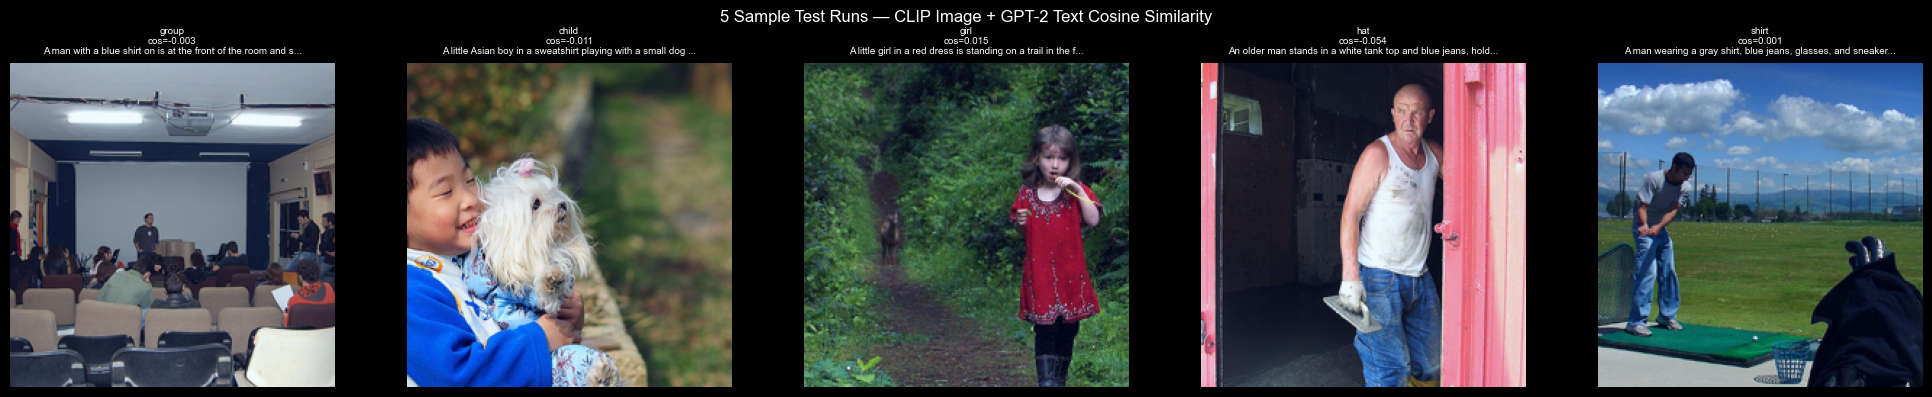

Saved to outputs/sample_test_runs.png


In [11]:
import matplotlib.pyplot as plt

# Pick 5 samples from different classes
rng = np.random.RandomState(42)
seen_classes = set()
sample_indices = []
for idx in rng.permutation(len(valid_samples)):
    cls = valid_samples[idx]['label']
    if cls not in seen_classes:
        seen_classes.add(cls)
        sample_indices.append(idx)
    if len(sample_indices) == 5:
        break

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, idx in zip(axes, sample_indices):
    sample = valid_samples[idx]
    img_emb = data['image_embeddings'][idx]
    txt_emb = data['text_embeddings'][idx]

    # Cosine similarity
    cos_sim = np.dot(img_emb, txt_emb) / (np.linalg.norm(img_emb) * np.linalg.norm(txt_emb))

    # Denormalize CLIP image for display
    img_tensor = sample['pixel_values'].permute(1, 2, 0).numpy()
    img_display = (img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min())

    caption_short = sample['caption'][:60] + ('...' if len(sample['caption']) > 60 else '')

    ax.imshow(img_display)
    ax.set_title(f"{sample['label']}\ncos={cos_sim:.3f}\n{caption_short}", fontsize=7)
    ax.axis('off')

plt.suptitle('5 Sample Test Runs — CLIP Image + GPT-2 Text Cosine Similarity', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/sample_test_runs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/sample_test_runs.png')

## Section 8 — Summary

In [12]:
print('=' * 60)
print('M1 EXTRACTION COMPLETE')
print('=' * 60)
print(f'Dataset        : {config["dataset"]["name"]}')
print(f'Classes        : {config["dataset"]["classes"]}')
print(f'Total samples  : {len(data["ids"])}')
print(f'Image emb shape: {data["image_embeddings"].shape}')
print(f'Text emb shape : {data["text_embeddings"].shape}')
print(f'Repair rate    : {preprocess_result.repair_rate:.1%}')
print(f'Skip rate      : {preprocess_result.skip_rate:.1%}')
print(f'Output file    : {output_path}')
print(f'Sample plots   : outputs/sample_test_runs.png')
print('=' * 60)

M1 EXTRACTION COMPLETE
Dataset        : nlphuji/flickr30k
Classes        : ['man', 'shirt', 'woman', 'people', 'tree', 'hat', 'girl', 'boy', 'group', 'child']
Total samples  : 1000
Image emb shape: (1000, 512)
Text emb shape : (1000, 512)
Repair rate    : 0.0%
Skip rate      : 0.0%
Output file    : D:\NEU\Generative_Project_1\outputs\embeddings.npz
Sample plots   : outputs/sample_test_runs.png
